In [1]:
!unzip -q "/content/drive/MyDrive/PlotQA-Stemsight/dot_line_data.zip" -d /content/dataset_line
print("✅ Step 1: Unzip Complete!")

✅ Step 1: Unzip Complete!


In [2]:
import torch
import os
from transformers import DonutProcessor, VisionEncoderDecoderModel

# Paths
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"

# Load Model & Processor
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path)

# Device Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.config.tie_word_embeddings = False
print(f"✅ Step 2: Model Loaded on {device.upper()}")

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Step 2: Model Loaded on CUDA


In [3]:
from datasets import load_dataset

# Load ImageFolder
full_dataset = load_dataset("imagefolder", data_dir="/content/dataset_line/train", split="train")

# Sirf 10,000 samples
dataset_10k = full_dataset.select(range(10000))

# Column Detection
all_cols = dataset_10k.column_names
text_col = [col for col in all_cols if col not in ['image', 'file_name']][0]

print(f"✅ Step 3: 10k Samples Ready. Using '{text_col}' for training.")

Resolving data files:   0%|          | 0/26011 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

✅ Step 3: 10k Samples Ready. Using 'ground_truth' for training.


In [4]:
import multiprocessing

def preprocess_fn(examples):
    # Image processing
    pixel_values = processor([img.convert("RGB") for img in examples["image"]], return_tensors="pt").pixel_values
    # Text processing
    labels = processor.tokenizer(examples[text_col], padding="max_length", max_length=512, truncation=True).input_ids
    return {"pixel_values": pixel_values, "labels": labels}

# Train/Test Split (9k training, 1k validation for accuracy)
split_ds = dataset_10k.train_test_split(test_size=0.1)

# FAST MAPPING using num_proc
train_ds = split_ds["train"].map(preprocess_fn, batched=True, batch_size=8, num_proc=multiprocessing.cpu_count(), remove_columns=all_cols)
eval_ds = split_ds["test"].map(preprocess_fn, batched=True, batch_size=8, num_proc=multiprocessing.cpu_count(), remove_columns=all_cols)

print("✅ Step 4: Mapping Done in Record Time!")

Map (num_proc=2):   0%|          | 0/9000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

✅ Step 4: Mapping Done in Record Time!


In [14]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, TrainerCallback
import torch

# --- Custom Callback: Jo force-print karega logs ko ---
class PrinterCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if "loss" in logs:
                print(f"📉 Step {state.global_step}: Training Loss = {logs['loss']:.4f}")
            if "eval_loss" in logs:
                print(f"🌟 Step {state.global_step}: VALIDATION LOSS = {logs['eval_loss']:.4f}")

training_args = Seq2SeqTrainingArguments(
    output_dir="./STEM_Sight_Line_Expert_V2",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    max_steps=2000,
    learning_rate=2e-5,
    fp16=True,


    eval_strategy="steps",
    eval_steps=200,
    per_device_eval_batch_size=4,
    predict_with_generate=False,

    logging_steps=10,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=1,

    remove_unused_columns=False,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=fast_eval_ds,
    data_collator=collate_fn,
    processing_class=processor.tokenizer,
    callbacks=[PrinterCallback()]    # <--- Ye callback logs ko force-print karega
)

print("🚀 Starting Training... Logs will appear below as text.")

# Resume karne ke liye:
# trainer.train(resume_from_checkpoint=True)

# Naye sire se start karne ke liye:
trainer.train()

🚀 Starting Training... Logs will appear below as text.


Step,Training Loss,Validation Loss
200,0.001397,0.001853
400,0.003880,0.002081
600,0.002758,0.001412
800,0.006064,0.001450
1000,0.003006,0.001051
1200,0.001836,0.000793
1400,0.003381,0.000908
1600,0.001947,0.000778
1800,0.002090,0.000767
2000,0.002018,0.000751


📉 Step 10: Training Loss = 0.0006
📉 Step 20: Training Loss = 0.0006
📉 Step 30: Training Loss = 0.0013
📉 Step 40: Training Loss = 0.0020
📉 Step 50: Training Loss = 0.0050
📉 Step 60: Training Loss = 0.0026
📉 Step 70: Training Loss = 0.0033
📉 Step 80: Training Loss = 0.0018
📉 Step 90: Training Loss = 0.0018
📉 Step 100: Training Loss = 0.0025
📉 Step 110: Training Loss = 0.0021
📉 Step 120: Training Loss = 0.0008
📉 Step 130: Training Loss = 0.0027
📉 Step 140: Training Loss = 0.0025
📉 Step 150: Training Loss = 0.0043
📉 Step 160: Training Loss = 0.0023
📉 Step 170: Training Loss = 0.0037
📉 Step 180: Training Loss = 0.0007
📉 Step 190: Training Loss = 0.0013
📉 Step 200: Training Loss = 0.0014
🌟 Step 200: VALIDATION LOSS = 0.0019
📉 Step 210: Training Loss = 0.0016
📉 Step 220: Training Loss = 0.0010
📉 Step 230: Training Loss = 0.0018
📉 Step 240: Training Loss = 0.0015
📉 Step 250: Training Loss = 0.0043
📉 Step 260: Training Loss = 0.0040
📉 Step 270: Training Loss = 0.0031
📉 Step 280: Training Loss =

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

📉 Step 510: Training Loss = 0.0014
📉 Step 520: Training Loss = 0.0023
📉 Step 530: Training Loss = 0.0032
📉 Step 540: Training Loss = 0.0014
📉 Step 550: Training Loss = 0.0022
📉 Step 560: Training Loss = 0.0016
📉 Step 570: Training Loss = 0.0017
📉 Step 580: Training Loss = 0.0019
📉 Step 590: Training Loss = 0.0021
📉 Step 600: Training Loss = 0.0028
🌟 Step 600: VALIDATION LOSS = 0.0014
📉 Step 610: Training Loss = 0.0021
📉 Step 620: Training Loss = 0.0032
📉 Step 630: Training Loss = 0.0028
📉 Step 640: Training Loss = 0.0025
📉 Step 650: Training Loss = 0.0044
📉 Step 660: Training Loss = 0.0042
📉 Step 670: Training Loss = 0.0066
📉 Step 680: Training Loss = 0.0070
📉 Step 690: Training Loss = 0.0036
📉 Step 700: Training Loss = 0.0055
📉 Step 710: Training Loss = 0.0060
📉 Step 720: Training Loss = 0.0049
📉 Step 730: Training Loss = 0.0037
📉 Step 740: Training Loss = 0.0097
📉 Step 750: Training Loss = 0.0038
📉 Step 760: Training Loss = 0.0045
📉 Step 770: Training Loss = 0.0056
📉 Step 780: Traini

...

📉 Step 1010: Training Loss = 0.0033
📉 Step 1020: Training Loss = 0.0033
📉 Step 1030: Training Loss = 0.0029
📉 Step 1040: Training Loss = 0.0028
📉 Step 1050: Training Loss = 0.0035
📉 Step 1060: Training Loss = 0.0031
📉 Step 1070: Training Loss = 0.0040
📉 Step 1080: Training Loss = 0.0019
📉 Step 1090: Training Loss = 0.0028
📉 Step 1100: Training Loss = 0.0034
📉 Step 1110: Training Loss = 0.0026
📉 Step 1120: Training Loss = 0.0017
📉 Step 1130: Training Loss = 0.0022
📉 Step 1140: Training Loss = 0.0058
📉 Step 1150: Training Loss = 0.0023
📉 Step 1160: Training Loss = 0.0016
📉 Step 1170: Training Loss = 0.0065
📉 Step 1180: Training Loss = 0.0015
📉 Step 1190: Training Loss = 0.0034
📉 Step 1200: Training Loss = 0.0018
🌟 Step 1200: VALIDATION LOSS = 0.0008
📉 Step 1210: Training Loss = 0.0029
📉 Step 1220: Training Loss = 0.0031
📉 Step 1230: Training Loss = 0.0047
📉 Step 1240: Training Loss = 0.0018
📉 Step 1250: Training Loss = 0.0031
📉 Step 1260: Training Loss = 0.0037
📉 Step 1270: Training Loss

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

📉 Step 1510: Training Loss = 0.0026
📉 Step 1520: Training Loss = 0.0038
📉 Step 1530: Training Loss = 0.0036
📉 Step 1540: Training Loss = 0.0013
📉 Step 1550: Training Loss = 0.0030
📉 Step 1560: Training Loss = 0.0015
📉 Step 1570: Training Loss = 0.0018
📉 Step 1580: Training Loss = 0.0112
📉 Step 1590: Training Loss = 0.0024
📉 Step 1600: Training Loss = 0.0019
🌟 Step 1600: VALIDATION LOSS = 0.0008
📉 Step 1610: Training Loss = 0.0010
📉 Step 1620: Training Loss = 0.0011
📉 Step 1630: Training Loss = 0.0032
📉 Step 1640: Training Loss = 0.0044
📉 Step 1650: Training Loss = 0.0018
📉 Step 1660: Training Loss = 0.0015
📉 Step 1670: Training Loss = 0.0026
📉 Step 1680: Training Loss = 0.0037
📉 Step 1690: Training Loss = 0.0012
📉 Step 1700: Training Loss = 0.0011
📉 Step 1710: Training Loss = 0.0008
📉 Step 1720: Training Loss = 0.0036
📉 Step 1730: Training Loss = 0.0008
📉 Step 1740: Training Loss = 0.0028
📉 Step 1750: Training Loss = 0.0033
📉 Step 1760: Training Loss = 0.0011
📉 Step 1770: Training Loss

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2000, training_loss=0.002865131620084867, metrics={'train_runtime': 4497.7511, 'train_samples_per_second': 1.779, 'train_steps_per_second': 0.445, 'total_flos': 4.252616903098368e+18, 'train_loss': 0.002865131620084867, 'epoch': 0.8888888888888888})

In [15]:
import torch
from tqdm.auto import tqdm
import numpy as np

# 1. Model ko evaluation mode mein daalo
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 2. Validation ka subset select karo testing ke liye
test_ds = eval_ds.select(range(min(200, len(eval_ds))))
predictions = []
references = []

print(f"🧐 Checking accuracy on {len(test_ds)} images...")

for sample in tqdm(test_ds):
    # Image prepare karo
    pixel_values = torch.tensor(sample["pixel_values"]).unsqueeze(0).to(device)

    # Model se text generate karwao
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=512,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    # Decode karo
    pred_text = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    # Asli label decode karo (-100 ko ignore karke)
    labels = np.where(sample["labels"] != -100, sample["labels"], processor.tokenizer.pad_token_id)
    ref_text = processor.tokenizer.decode(labels, skip_special_tokens=True)

    predictions.append(pred_text.strip().lower())
    references.append(ref_text.strip().lower())

# 3. Accuracy calculate karo
correct = sum([1 for p, r in zip(predictions, references) if p == r])
accuracy = (correct / len(references)) * 100

print(f"\n--- 📊 FINAL TEST RESULTS ---")
print(f"✅ Exact Match Accuracy: {accuracy:.2f}%")
print(f"📝 Total Images Tested: {len(references)}")

# Sample predictions dekhne ke liye
print("\n👀 Sample Predictions:")
for i in range(min(5, len(predictions))):
    print(f"Actual: {references[i]}")
    print(f"Pred  : {predictions[i]}")
    print("-" * 30)

🧐 Checking accuracy on 200 images...


  0%|          | 0/200 [00:00<?, ?it/s]


--- 📊 FINAL TEST RESULTS ---
✅ Exact Match Accuracy: 90.50%
📝 Total Images Tested: 200

👀 Sample Predictions:
Actual: {"gt_parse": "this is a dot line titled 'nitrous oxide emission due to industrial production'. the x-axis shows years and the y-axis shows emission (in thousand metric tons of co2 equivalent)."}
Pred  : {"gt_parse": "this is a dot line titled 'nitrous oxide emission due to industrial production'. the x-axis shows years and the y-axis shows emission (in thousand metric tons of co2 equivalent)."}
------------------------------
Actual: {"gt_parse": "this is a dot line titled 'strength of legal rights index'. the x-axis shows years and the y-axis shows strength index( 0 = weak,12 = strong)."}
Pred  : {"gt_parse": "this is a dot line titled 'strength of legal rights index'. the x-axis shows years and the y-axis shows strength index( 0 = weak,12 = strong)."}
------------------------------
Actual: {"gt_parse": "this is a dot line titled 'official aid vs net official developme

In [16]:
from google.colab import files
from PIL import Image
import torch
import io

# 1. File Upload ka option trigger karein
print("📤 Apni graph image (Dot-Line) select karein:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Image ko memory se load karein
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    # Model ke liye prepare karein
    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"\n🔍 Processing: {filename}...")

    # Inference (Prediction)
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,         # Pura caption aane ke liye
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    # Result decode karein
    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("✨ Model Prediction:")
    print(prediction)
    print("-" * 50)

📤 Apni graph image (Dot-Line) select karein:


Saving 31.png to 31.png


The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



🔍 Processing: 31.png...
✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'Employment to population ratio of the male population of Belize for different age-groups'. The x-axis shows Year and the y-axis shows Employment to population ratio(%)."}
--------------------------------------------------


In [ ]:
from google.colab import files
from PIL import Image
import torch
import io

print("upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"\n Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("Model Prediction:")
    print(prediction)


📊 Upload the dot line chart here:


Saving 7.png to 7.png


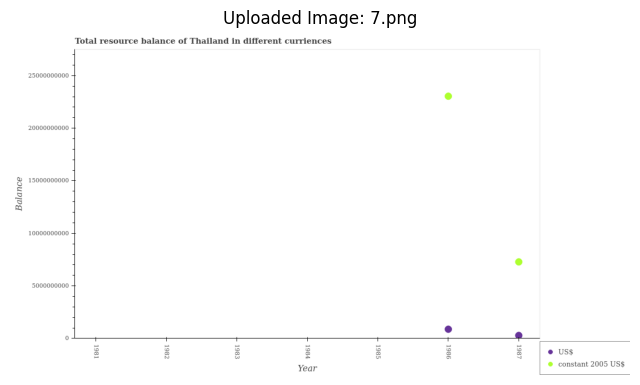

Processing: 7.png...

✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'Total resource balance of Thailand in different curriences'. The x-axis shows Year and the y-axis shows Balance."}


In [17]:
from google.colab import files
from PIL import Image
import torch
import io
import matplotlib.pyplot as plt

print("📊 Upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Uploaded Image: {filename}")
    plt.show()

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("\n✨ Model Prediction:")
    print(prediction)

📊 Upload the dot line chart here:


Saving 80.png to 80.png


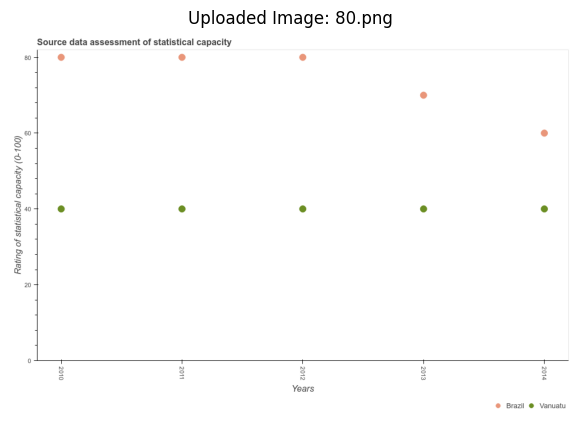

Processing: 80.png...

✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'Source data assessment of statistical capacity'. The x-axis shows Years and the y-axis shows Rating of statistical capacity (0-100)."}


In [18]:
from google.colab import files
from PIL import Image
import torch
import io
import matplotlib.pyplot as plt

print("📊 Upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Uploaded Image: {filename}")
    plt.show()

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("\n✨ Model Prediction:")
    print(prediction)

📊 Upload the dot line chart here:


Saving 389.png to 389.png


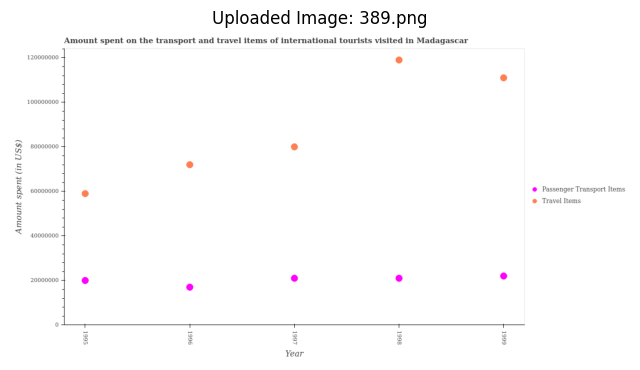

Processing: 389.png...

✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'Amount spent on the transport and travel items of international tourists visited in Madagascar'. The x-axis shows Year and the y-axis shows Amount spent (in US$)."}


In [19]:
from google.colab import files
from PIL import Image
import torch
import io
import matplotlib.pyplot as plt

print("📊 Upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Uploaded Image: {filename}")
    plt.show()

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("\n✨ Model Prediction:")
    print(prediction)

📊 Upload the dot line chart here:


Saving 786.png to 786.png


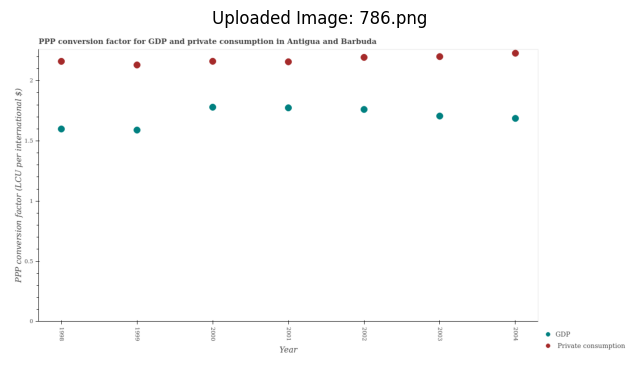

Processing: 786.png...

✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'PPP conversion factor for GDP and private consumption in children and Barbuda'. The x-axis shows Year and the y-axis shows PPP conversion factor (LCU per international $)."}


In [24]:
from google.colab import files
from PIL import Image
import torch
import io
import matplotlib.pyplot as plt

print("📊 Upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Uploaded Image: {filename}")
    plt.show()

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("\n✨ Model Prediction:")
    print(prediction)

📊 Upload the dot line chart here:


Saving 1222.png to 1222.png


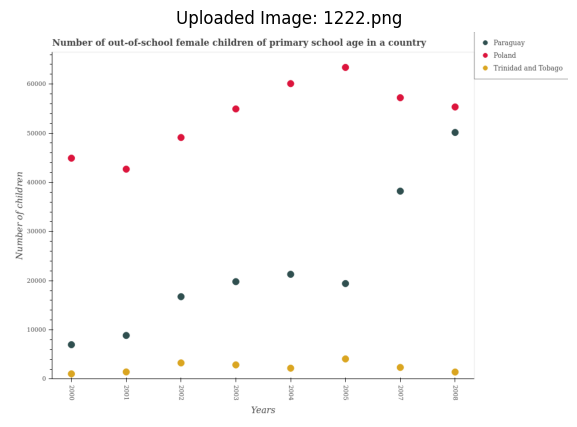

Processing: 1222.png...

✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'Number of out-of-school female children of primary school age in a country'. The x-axis shows Years and the y-axis shows Number of children."}


In [25]:
from google.colab import files
from PIL import Image
import torch
import io
import matplotlib.pyplot as plt

print("📊 Upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Uploaded Image: {filename}")
    plt.show()

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("\n✨ Model Prediction:")
    print(prediction)

📊 Upload the dot line chart here:


Saving 1577.png to 1577.png


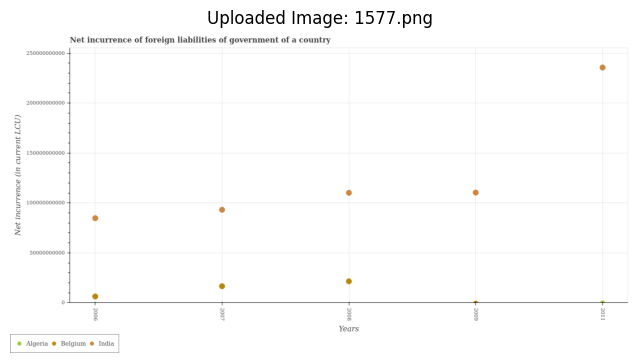

Processing: 1577.png...

✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'Net incurrence of foreign liabilities of government of a country'. The x-axis shows Years and the y-axis shows Net incurrence (in current LCU)."}


In [26]:
from google.colab import files
from PIL import Image
import torch
import io
import matplotlib.pyplot as plt

print("📊 Upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Uploaded Image: {filename}")
    plt.show()

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("\n✨ Model Prediction:")
    print(prediction)

📊 Upload the dot line chart here:


Saving 631.png to 631.png


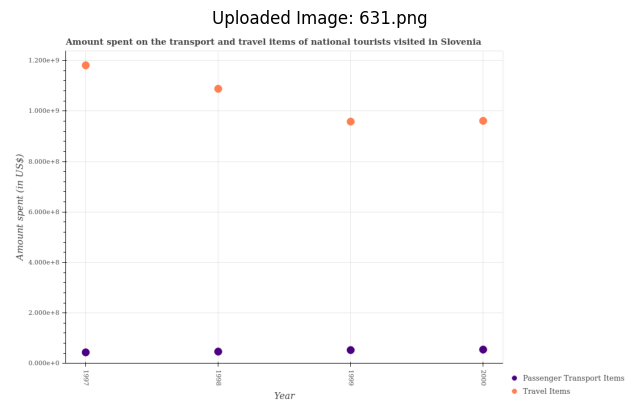

Processing: 631.png...

✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'Amount spent on the transport and travel items of national tourists visited in Slovenia'. The x-axis shows Year and the y-axis shows Amount spent (in US$)."}


In [27]:
from google.colab import files
from PIL import Image
import torch
import io
import matplotlib.pyplot as plt

print("📊 Upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Uploaded Image: {filename}")
    plt.show()

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("\n✨ Model Prediction:")
    print(prediction)

📊 Upload the dot line chart here:


Saving 1025.png to 1025.png


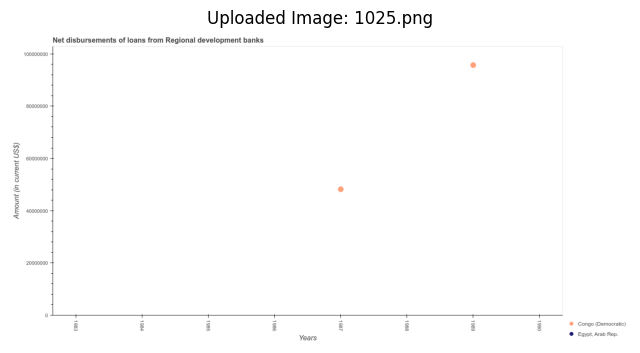

Processing: 1025.png...

✨ Model Prediction:
{"gt_parse": "This is a dot line titled 'Net disbursements of loans from Regional development banks'. The x-axis shows Years and the y-axis shows Amount (in current US$)."}


In [28]:
from google.colab import files
from PIL import Image
import torch
import io
import matplotlib.pyplot as plt

print("📊 Upload the dot line chart here:")
uploaded = files.upload()

for filename in uploaded.keys():
    image_data = uploaded[filename]
    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Uploaded Image: {filename}")
    plt.show()

    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    print(f"Processing: {filename}...")

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            max_length=768,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    prediction = processor.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print("\n✨ Model Prediction:")
    print(prediction)

In [29]:
import os

folder_to_zip = "STEM_Sight_Line_Expert_V2"
zip_file = "STEM_Sight_Line_Expert_Model.zip"

!zip -r {zip_file} {folder_to_zip}

print(f"✅ Zip file ready: {zip_file}")

  adding: STEM_Sight_Line_Expert_V2/ (stored 0%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/ (stored 0%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/trainer_state.json (deflated 81%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/config.json (deflated 74%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/training_args.bin (deflated 53%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/scaler.pt (deflated 64%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/model.safetensors (deflated 7%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/optimizer.pt (deflated 30%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/tokenizer.json (deflated 74%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/scheduler.pt (deflated 61%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/tokenizer_config.json (deflated 53%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/rng_state.pth (deflated 26%)
  adding: STEM_Sight_Line_Expert_V2/checkpoint-2000/generation_

In [30]:
from google.colab import files
import os

if os.path.exists("STEM_Sight_Line_Expert_Model.zip"):
    files.download("STEM_Sight_Line_Expert_Model.zip")
else:
    print("Abhi bhi file nahi mili! Sidebar mein refresh karke dekho.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>